 # Apply the Perceptron and Adaline models to the classes/feature: 
 ### The objective of this lab is to understand and play with Perceptron and Adaline models 
 * Both perceptron and Adaline have similar accuracy until additional features started being included. In which case we see a dramatic decrease in the accuracy. I am not sure exactly why 

In [1]:
from sklearn import datasets
from sklearn import metrics
import numpy as np
import pandas as pd
from sklearn.linear_model import Perceptron
import matplotlib.pyplot as plt



In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
df = pd.read_csv(url,
     header=None,
     encoding='utf-8')

y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', -1, 1)


X = df.iloc[0:100, [0, 2]].values
df

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


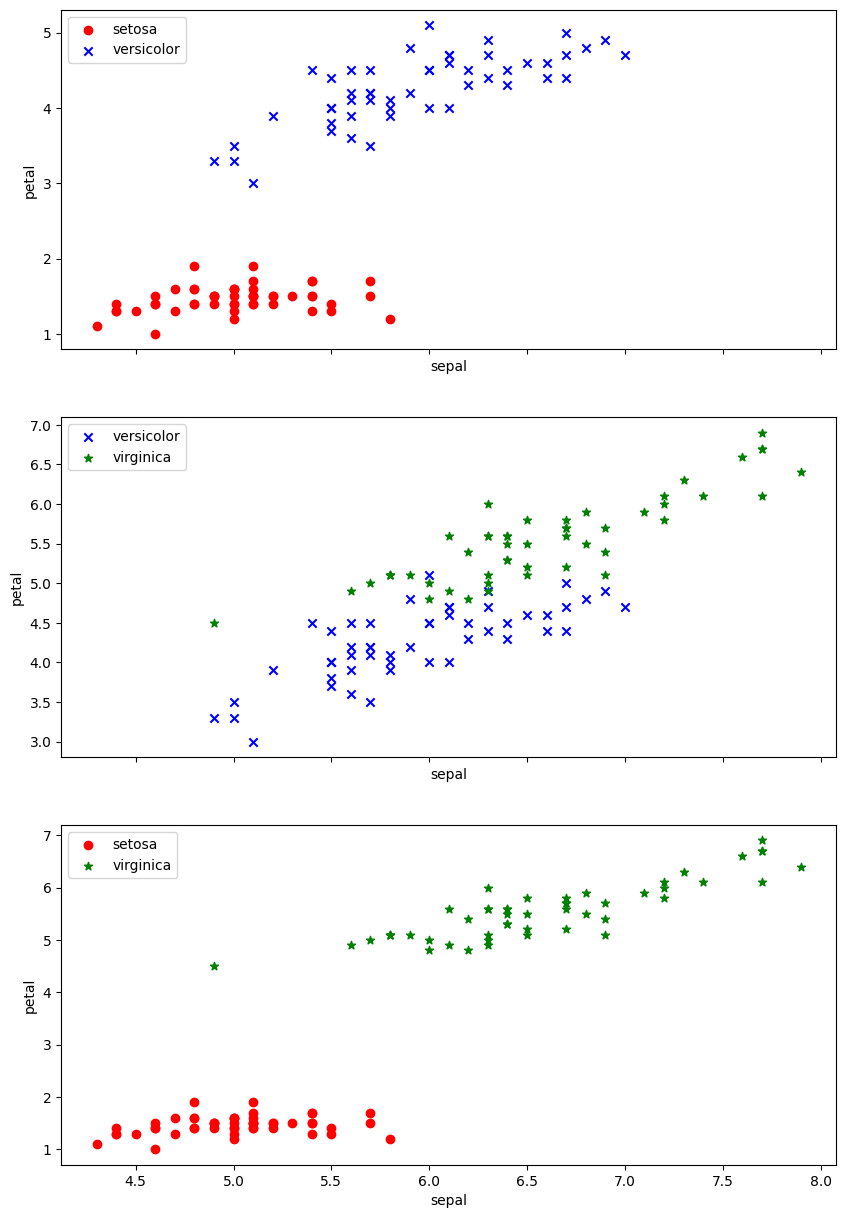

In [3]:
plt.close('all')

fig, ax = plt.subplots(nrows=3, ncols=1, figsize = (10,15), sharex=True)


y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', -1, 1)


X = df.iloc[0:100, [0, 2]].values

ax[0].scatter(X[:50, 0], X[:50, 1],
   color = 'red', marker = 'o', label = 'setosa')
ax[0].scatter(X[50:100, 0], X[50:100, 1],
   color = 'blue', marker = 'x', label = 'versicolor')

ax[0].set_xlabel('sepal')
ax[0].set_ylabel('petal')
ax[0].legend(loc = 'upper left')



y = df.iloc[50:150, 4].values
y = np.where(y == 'Iris-versicolor', -1, 1)


X = df.iloc[50:150, [0, 2]].values

ax[1].scatter(X[:50, 0], X[:50, 1],
   color = 'blue', marker = 'x', label = 'versicolor')
ax[1].scatter(X[50:100, 0], X[50:100, 1],
   color = 'green', marker = '*', label = 'virginica')

ax[1].set_xlabel('sepal')
ax[1].set_ylabel('petal')
ax[1].legend(loc = 'upper left')



y1 = df.iloc[0:50, 4].values
y2 = df.iloc[100:150, 4].values
x1 = df.iloc[0:50, [0, 2]].values
x2 = df.iloc[100:150, [0, 2]].values

ax[2].scatter(x1[:50, 0], x1[:50, 1],
   color = 'red', marker = 'o', label = 'setosa')
ax[2].scatter(x2[:50, 0], x2[:50, 1],
   color = 'green', marker = '*', label = 'virginica')

ax[2].set_xlabel('sepal')
ax[2].set_ylabel('petal')
ax[2].legend(loc = 'upper left')


/var/folders/02/btt_fn551m7dkj4bhlphf3240000gn/T/ipykernel_935/732903214.py:34: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


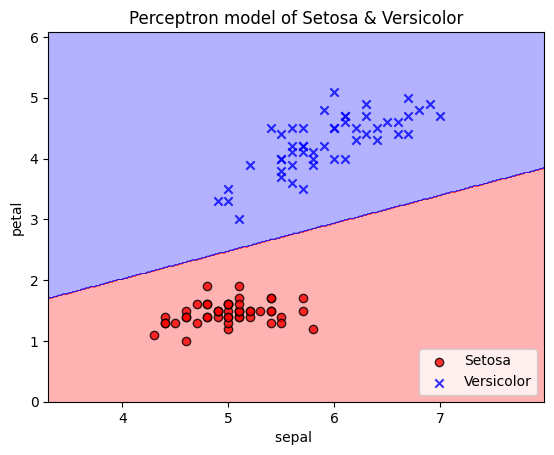

In [4]:

from matplotlib.colors import ListedColormap
y_percep1 = df.iloc[0:100, 4].values
y_percep1 = np.where(y_percep1 == 'Iris-setosa', -1, 1)


X_percep1 = df.iloc[0:100, [0, 2]].values


perceptron_model = Perceptron(eta0=0.1, max_iter=10)
perceptron_model.fit(X_percep1, y_percep1)




def plot_decision_regions(X, y, classifier, resolution=0.02):

    markers = ('o', 'x', '*')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

  
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
      np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

   
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
            y=X[y == cl, 1],
            alpha=0.8, 
            c=colors[idx],
            marker=markers[idx],
            label=cl, 
            edgecolor='black')
plot_decision_regions(X_percep1, y_percep1, classifier = perceptron_model)
plt.title('Perceptron model of Setosa & Versicolor')
plt.xlabel('sepal ')
plt.ylabel('petal')

L = plt.legend(loc = 'lower right')
L.get_texts()[0].set_text("Setosa")
L.get_texts()[1].set_text("Versicolor")

plt.show()

# Adaline Model: Textbook portion

In [5]:
class Adaline(object):
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()
            cost = (errors**2).sum() / 2.0
            self.cost_.append(cost)
        return self

    def net_input(self, X):
        
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        
        return X

    def predict(self, X):
        
        return np.where(self.activation(self.net_input(X)) >= 0.0, 1, -1)

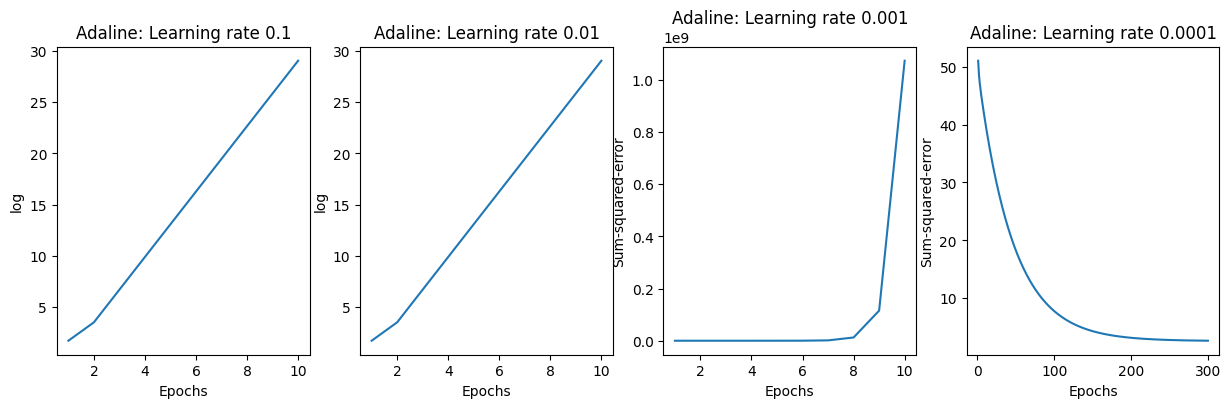

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows = 1, ncols = 4, figsize = (15, 4))

ada1 = Adaline(n_iter = 10, eta = 0.01).fit(X_percep1, y_percep1)
ax[0].plot(range(1, len(ada1.cost_) + 1), np.log10(ada1.cost_))
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('log')
ax[0].set_title('Adaline: Learning rate 0.1')

ada2 = Adaline(n_iter = 10, eta = 0.01).fit(X_percep1, y_percep1)
ax[1].plot(range(1, len(ada2.cost_) + 1), np.log10(ada2.cost_))
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('log')
ax[1].set_title('Adaline: Learning rate 0.01')

ada3 = Adaline(n_iter = 10, eta = 0.001).fit(X_percep1, y_percep1)
ax[2].plot(range(1, len(ada3.cost_) + 1), ada3.cost_)
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Sum-squared-error')
ax[2].set_title('Adaline: Learning rate 0.001')

ada4 = Adaline(n_iter = 300, eta = 0.0001).fit(X_percep1, y_percep1)
ax[3].plot(range(1, len(ada4.cost_) + 1), ada4.cost_)
ax[3].set_xlabel('Epochs')
ax[3].set_ylabel('Sum-squared-error')
ax[3].set_title('Adaline: Learning rate 0.0001')

plt.show()

In [13]:
X_std = np.copy(X_percep1)
X_std[:, 0] = (X_percep1[:, 0] - X_percep1[:, 0].mean()) / X_percep1[:, 0].std()
X_std[:, 1] = (X_percep1[:, 1] - X_percep1[:, 1].mean()) / X_percep1[:, 1].std()

/var/folders/02/btt_fn551m7dkj4bhlphf3240000gn/T/ipykernel_935/732903214.py:34: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


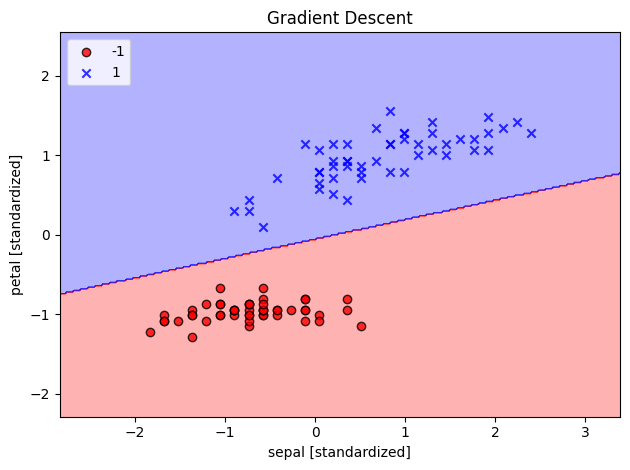

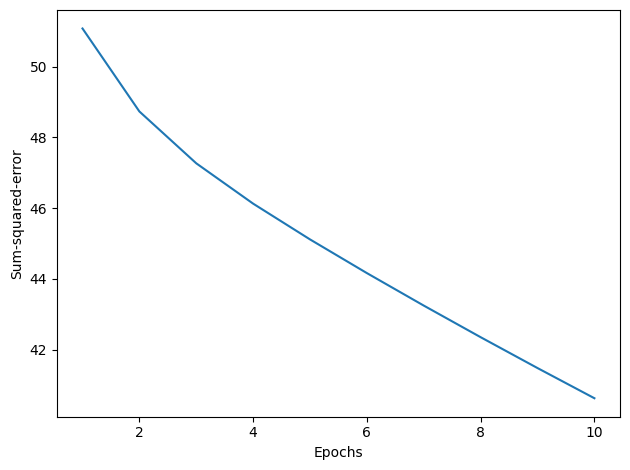

In [14]:
Feature1 = Adaline(n_iter=10, eta=0.0001)
Feature1.fit(X_percep1, y_percep1)

plot_decision_regions(X_std, y_percep1, classifier = Feature1)
plt.title('Gradient Descent')
plt.xlabel('sepal [standardized]')
plt.ylabel('petal [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

plt.plot(range(1, len(Feature1.cost_) + 1), Feature1.cost_)
plt.xlabel('Epochs')
plt.ylabel('Sum-squared-error')

plt.tight_layout()
plt.show()

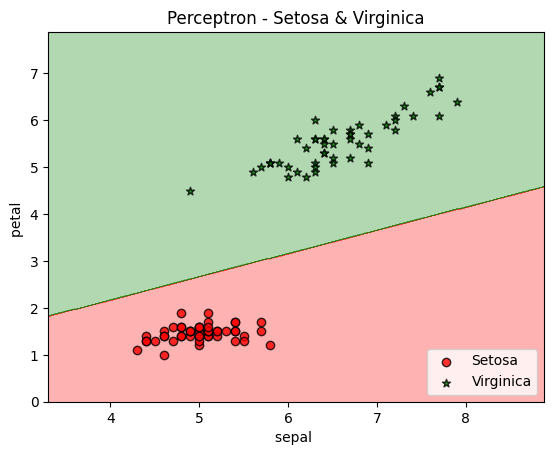

In [19]:
y1 = df.iloc[0:50, 4].values
y2 = df.iloc[100:150, 4].values
x1 = df.iloc[0:50, [0, 2]].values
x2 = df.iloc[100:150, [0, 2]].values

X = np.concatenate([x1, x2])
y = np.concatenate((y1, y2))


y = np.where(y == 'Iris-setosa', -1, 1)


perceptron = Perceptron(eta0=0.1, max_iter=10)
perceptron.fit(X, y)

from matplotlib.colors import ListedColormap


def plot_decision_regions(X, y, classifier, resolution=0.02):

    
    markers = ('o', '*')
    colors = ('red', 'green')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
            y=X[y == cl, 1],
            alpha=0.8, 
            c=colors[idx],
            marker=markers[idx], 
            label=cl, 
            edgecolor='black')
plot_decision_regions(X, y, classifier=perceptron)
plt.title('Perceptron: Setosa & Virginica')
plt.xlabel('sepal ')
plt.ylabel('petal ')

L = plt.legend(loc = 'lower right')
L.get_texts()[0].set_text("Setosa")
L.get_texts()[1].set_text("Virginica")

plt.show()

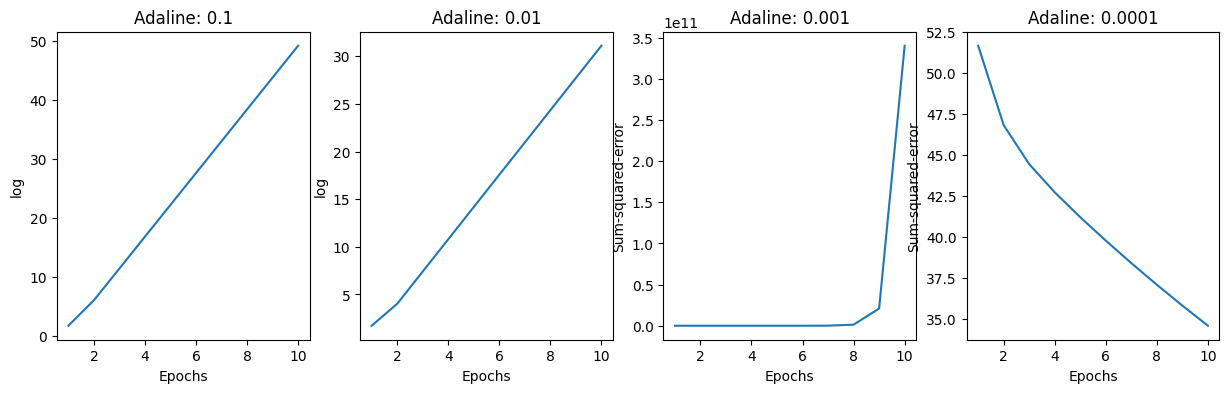

In [21]:
fig, ax = plt.subplots(nrows = 1, ncols = 4, figsize = (15, 4))

ada1 = Adaline(n_iter = 10, eta = 0.1).fit(X, y)
ax[0].plot(range(1, len(ada1.cost_) + 1), np.log10(ada1.cost_))
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('log')
ax[0].set_title('Adaline: 0.1')

ada2 = Adaline(n_iter = 10, eta = 0.01).fit(X, y)
ax[1].plot(range(1, len(ada2.cost_) + 1), np.log10(ada2.cost_))
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('log')
ax[1].set_title('Adaline: 0.01')

ada3 = Adaline(n_iter = 10, eta = 0.001).fit(X, y)
ax[2].plot(range(1, len(ada3.cost_) + 1), ada3.cost_)
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Sum-squared-error')
ax[2].set_title('Adaline: 0.001')

ada4 = Adaline(n_iter = 10, eta = 0.0001).fit(X, y)
ax[3].plot(range(1, len(ada4.cost_) + 1), ada4.cost_)
ax[3].set_xlabel('Epochs')
ax[3].set_ylabel('Sum-squared-error')
ax[3].set_title('Adaline: 0.0001')

plt.show()

In [ ]:
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()


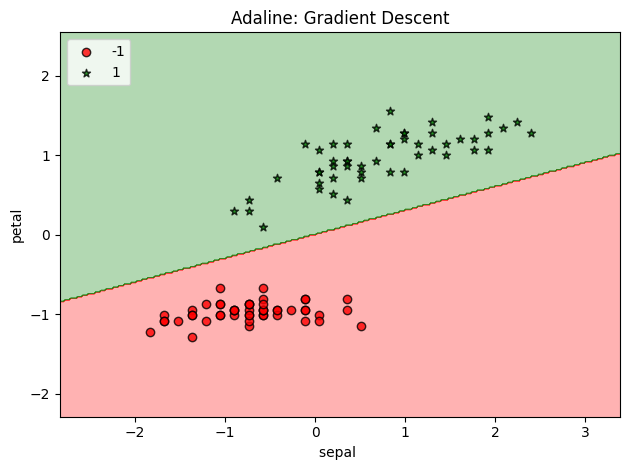

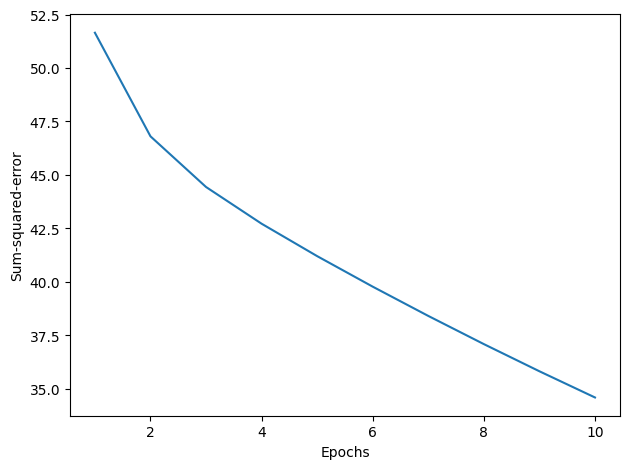

In [24]:
Adaline_Feature2 = Adaline(n_iter=10, eta=0.0001)
Adaline_Feature2.fit(X, y)

plot_decision_regions(X_std, y, classifier = Adaline_Feature2)
plt.title('Adaline: Gradient Descent')
plt.xlabel('sepal ')
plt.ylabel('petal')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

plt.plot(range(1, len(Adaline_Feature2.cost_) + 1), Adaline_Feature2.cost_)
plt.xlabel('Epochs')
plt.ylabel('Sum-squared-error')

plt.tight_layout()

plt.show()

## This time we will do not linearly separable 

In [25]:
y = df.iloc[50:150, 4].values
y = np.where(y == 'Iris-versicolor', -1, 1)


X = df.iloc[50:150, [0, 2]].values


## Perceptron model 2 features 


/var/folders/02/btt_fn551m7dkj4bhlphf3240000gn/T/ipykernel_935/3238392731.py:26: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


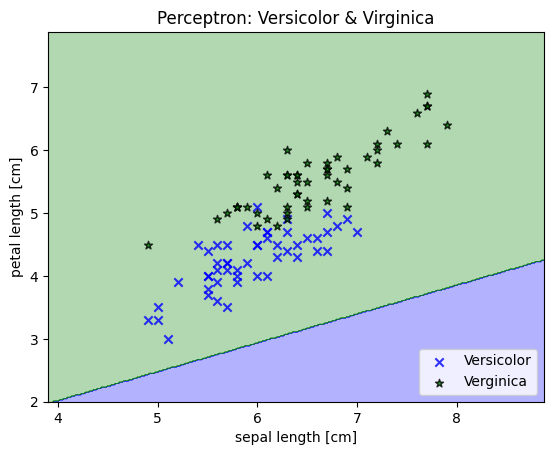

In [26]:
perceptron_model_not_linear = Perceptron(eta0=0.1, max_iter=30)
perceptron_model_not_linear.fit(X, y)

from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):

   
    markers = ('x', '*')
    colors = ('blue', 'green')
    cmap = ListedColormap(colors[:len(np.unique(y))])

   
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

   
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
            y=X[y == cl, 1],
            alpha=0.8, 
            c=colors[idx],
            marker=markers[idx], 
            label=cl, 
            edgecolor='black')

plot_decision_regions(X, y, classifier = perceptron_model)
plt.title('Perceptron: Versicolor & Virginica')
plt.xlabel('sepal ')
plt.ylabel('petal')

L = plt.legend(loc = 'lower right')
L.get_texts()[0].set_text("Versicolor")
L.get_texts()[1].set_text("Verginica")

plt.show()


## Scoring

In [27]:

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

y_pred = perceptron_model_not_linear.predict(X_test)
print("Accuracy score: ", accuracy_score(y_test, y_pred))



Accuracy score:  0.7666666666666667


In [28]:
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

/var/folders/02/btt_fn551m7dkj4bhlphf3240000gn/T/ipykernel_935/3238392731.py:26: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


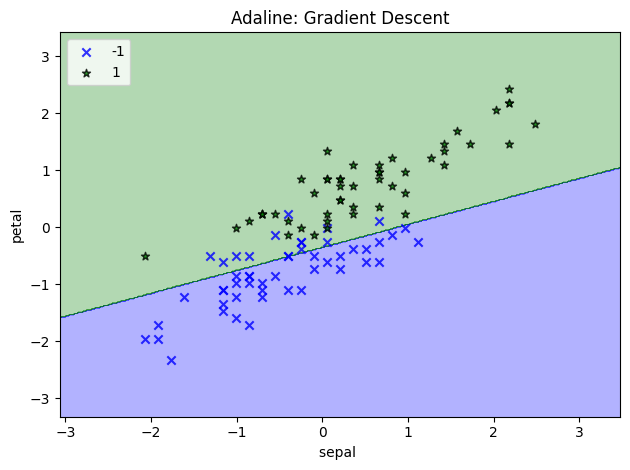

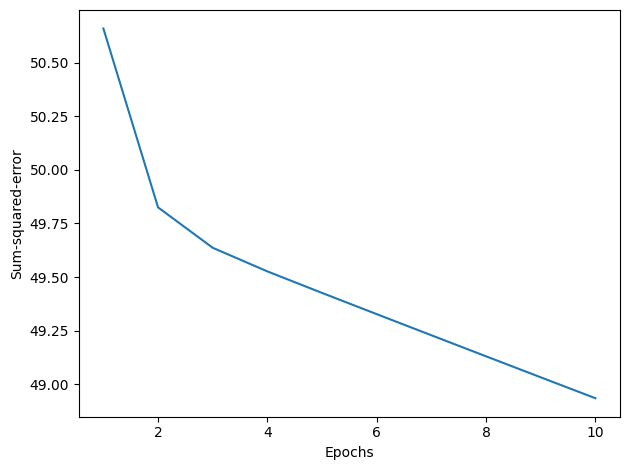

In [29]:
Adaline_1_not_linear = Adaline(n_iter=10, eta=0.0001)
Adaline_1_not_linear.fit(X, y)

plot_decision_regions(X_std, y, classifier = Adaline_1_not_linear)
plt.title('Adaline: Gradient Descent')
plt.xlabel('sepal ')
plt.ylabel('petal')
plt.legend(loc='upper left')
plt.tight_layout()

plt.show()

plt.plot(range(1, len(Adaline_1_not_linear.cost_) + 1), Adaline_1_not_linear.cost_)
plt.xlabel('Epochs')
plt.ylabel('Sum-squared-error')

plt.tight_layout()

plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

y_pred = Adaline_1_not_linear.predict(X_test)
print("Accuracy score: ", accuracy_score(y_test, y_pred))

Accuracy score:  0.5333333333333333


# This time we will do three features 

In [31]:
iris = datasets.load_iris()
IC = np.unique(y)

X = iris.data
y = iris.target



petal 
petal 
petal 
petal 
petal 
petal 
petal 
petal 
petal 
petal 
petal 
petal 


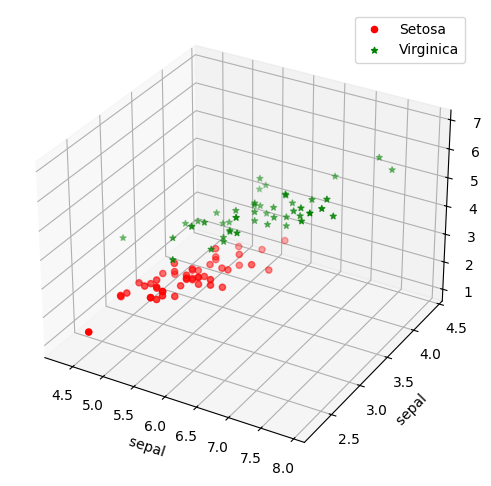

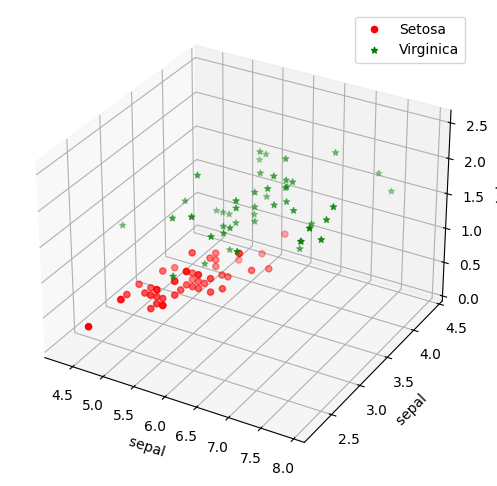

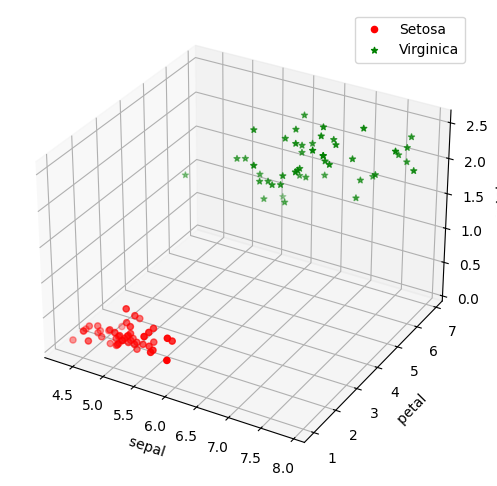

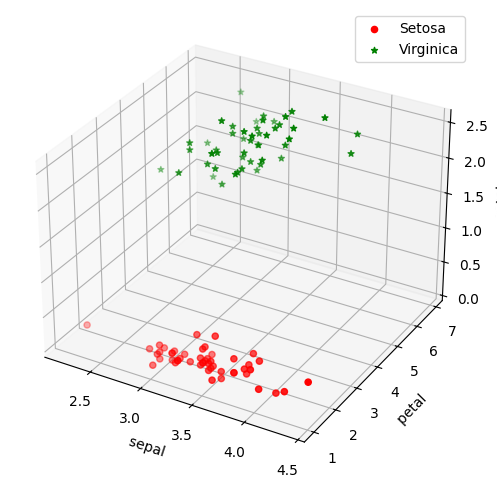

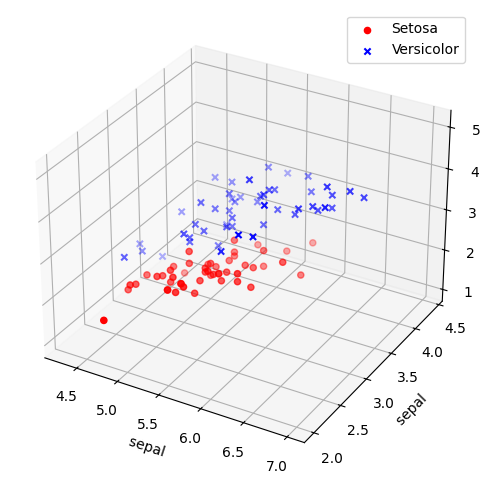

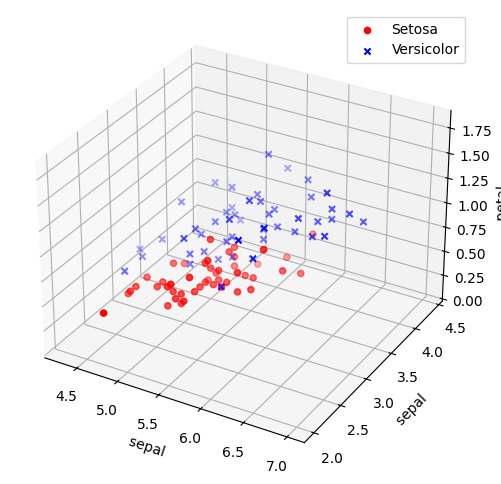

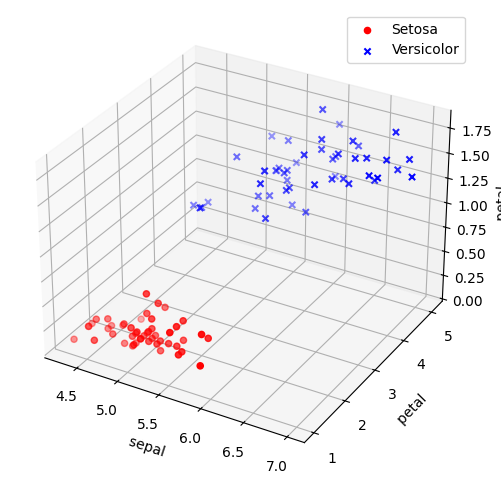

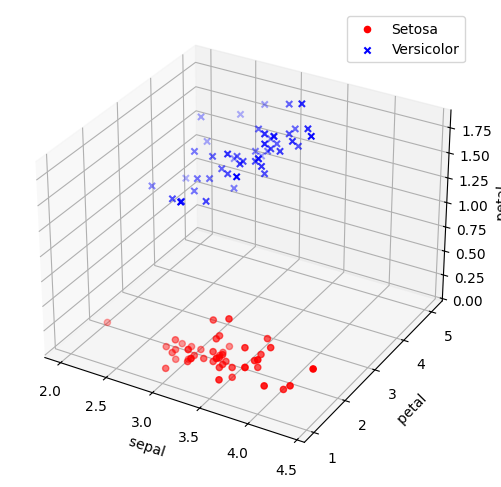

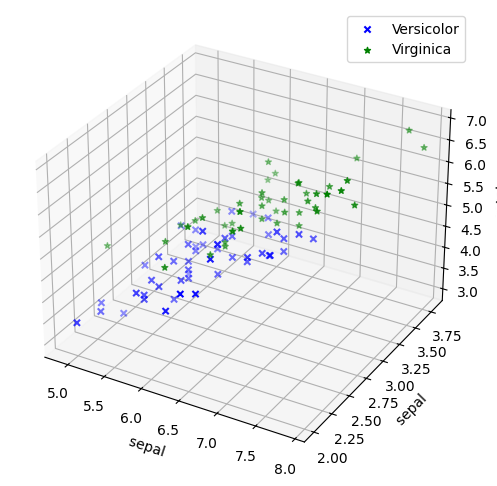

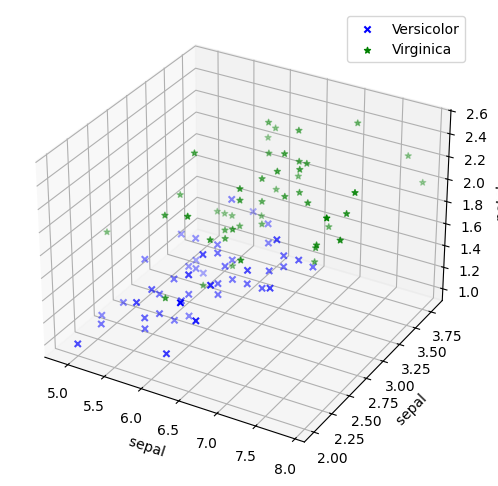

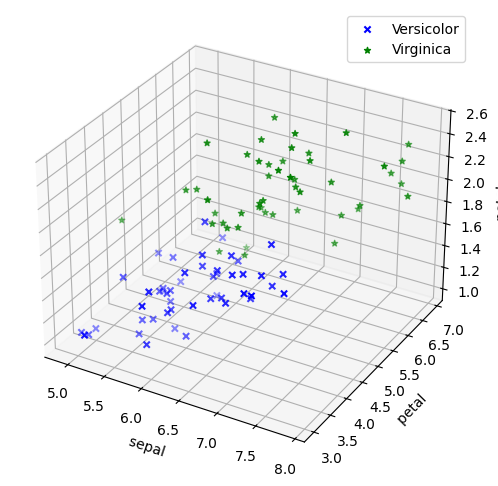

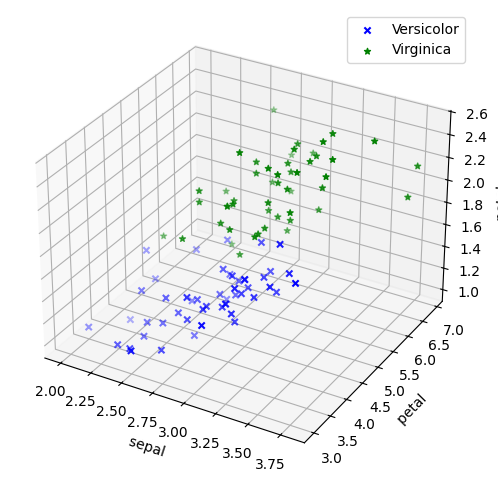

In [33]:
plt.close('all')

iris = datasets.load_iris()

X = iris.data
y = iris.target

IC = np.unique(y)

IrisClassification = ('Setosa', 'Versicolor', 'Virginica')
pltColor = ('red', 'blue', 'green')
IrisFeatures=("sepal ", "sepal ", "petal ", "petal ")

ix = [0,0,0,1]
iy = [1,1,2,2]
iz = [2,3,3,3]

for m in range(4):
    
    ixm = ix[m]
    iym = iy[m]
    izm = iz[m]
    xF = IrisFeatures[ixm]
    yF = IrisFeatures[iym]
    zF = IrisFeatures[izm]

    fig = plt.figure(figsize=(6,6))    
    ax = plt.axes(projection='3d')   
    
    ax.scatter3D(X[y == IC[0],ixm], X[y == IC[0],iym], X[y == IC[0],izm], 
        color=pltColor[0], marker = 'o', label=IrisClassification[0])
    ax.scatter3D(X[y == IC[2],ixm], X[y == IC[2],iym], X[y == IC[2],izm], 
        color=pltColor[2], marker = '*', label=IrisClassification[2])

    ax.set_xlabel(xF)
    ax.set_ylabel(yF)
    ax.set_zlabel(zF)
    print(zF)            
    ax.legend(loc='upper right', fontsize='medium')

for m in range(4):
    
    ixm = ix[m]
    iym = iy[m]
    izm = iz[m]
    xF = IrisFeatures[ixm]
    yF = IrisFeatures[iym]
    zF = IrisFeatures[izm]

    fig = plt.figure(figsize=(6,6))    
    ax = plt.axes(projection='3d')   
    
    ax.scatter3D(X[y == IC[0],ixm], X[y == IC[0],iym], X[y == IC[0],izm], 
        color=pltColor[0], marker = 'o', label=IrisClassification[0])
    ax.scatter3D(X[y == IC[1],ixm], X[y == IC[1],iym], X[y == IC[1],izm], 
        color=pltColor[1], marker = 'x', label=IrisClassification[1])

    ax.set_xlabel(xF)
    ax.set_ylabel(yF)
    ax.set_zlabel(zF)
    print(zF)            
    ax.legend(loc='upper right', fontsize='medium')

for m in range(4):
    
    ixm = ix[m]
    iym = iy[m]
    izm = iz[m]
    xF = IrisFeatures[ixm]
    yF = IrisFeatures[iym]
    zF = IrisFeatures[izm]

    fig = plt.figure(figsize=(6,6))    
    ax = plt.axes(projection='3d')   
    
    ax.scatter3D(X[y == IC[1],ixm], X[y == IC[1],iym], X[y == IC[1],izm], 
        color=pltColor[1], marker = 'x', label=IrisClassification[1])
    ax.scatter3D(X[y == IC[2],ixm], X[y == IC[2],iym], X[y == IC[2],izm], 
        color=pltColor[2], marker = '*', label=IrisClassification[2])

    ax.set_xlabel(xF)
    ax.set_ylabel(yF)
    ax.set_zlabel(zF)
    print(zF)            
    ax.legend(loc='upper right', fontsize='medium')

In [36]:
from sklearn.model_selection import train_test_split
y1 = df.iloc[0:50, 4].values
y2 = df.iloc[100:150, 4].values
x1 = df.iloc[0:50, [1, 2, 3]].values
x2 = df.iloc[100:150, [1, 2, 3]].values

X = np.concatenate([x1, x2])
y = np.concatenate((y1, y2))

y = np.where(y == 'Iris-setosa', -1, 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [39]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)


In [41]:
from sklearn.metrics import accuracy_score
Perceptron_3_Features1 = Perceptron(max_iter = 100, tol = .0001, n_jobs = -1, random_state = 1)

Perceptron_3_Features1.fit(X_train_std, y_train)

y_pred = Perceptron_3_Features1.predict(X_test_std)
print("Accuracy score: ", accuracy_score(y_test, y_pred))

Accuracy score:  1.0


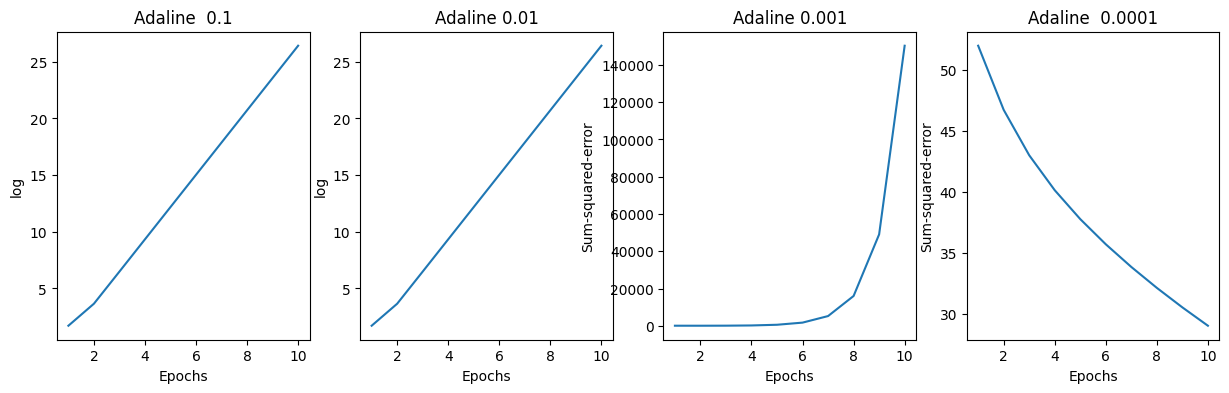

In [44]:
fig, ax = plt.subplots(nrows = 1, ncols = 4, figsize = (15, 4))

ada1 = Adaline(n_iter = 10, eta = 0.01).fit(X, y)
ax[0].plot(range(1, len(ada1.cost_) + 1), np.log10(ada1.cost_))
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('log')
ax[0].set_title('Adaline  0.1')

ada2 = Adaline(n_iter = 10, eta = 0.01).fit(X, y)
ax[1].plot(range(1, len(ada2.cost_) + 1), np.log10(ada2.cost_))
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('log')
ax[1].set_title('Adaline 0.01')

ada3 = Adaline(n_iter = 10, eta = 0.001).fit(X, y)
ax[2].plot(range(1, len(ada3.cost_) + 1), ada3.cost_)
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Sum-squared-error')
ax[2].set_title('Adaline 0.001')

ada4 = Adaline(n_iter = 10, eta = 0.0001).fit(X, y)
ax[3].plot(range(1, len(ada4.cost_) + 1), ada4.cost_)
ax[3].set_xlabel('Epochs')
ax[3].set_ylabel('Sum-squared-error')
ax[3].set_title('Adaline  0.0001')


plt.show()

In [45]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

Adaline_3_Features_linear = Adaline()
Adaline_3_Features_linear.fit(X_train_std, y_train)

y_pred = Adaline_3_Features_linear.predict(X_test_std)
print("Accuracy score: ", accuracy_score(y_test, y_pred))



Accuracy score:  1.0


# Not Linearly Separable 

In [46]:
from sklearn.model_selection import train_test_split

X = df.iloc[50: , [0, 1, 3]].values
y = df.iloc[50: , 4].values

y = np.where(y == 'Iris-versicolor', -1, 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [47]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)



In [48]:
from sklearn.metrics import accuracy_score
Perceptron_3_Features2 = Perceptron(max_iter = 100, tol = .0001, n_jobs = -1, random_state = 1)

Perceptron_3_Features2.fit(X_train_std, y_train)

y_pred = Perceptron_3_Features2.predict(X_test_std)
print("Accuracy score: ", accuracy_score(y_test, y_pred))

Accuracy score:  0.8666666666666667


In [50]:
from sklearn.linear_model import SGDClassifier

Adaline_3_Features2 = Adaline()
Adaline_3_Features2.fit(X_train_std,y_train)

y_pred = Adaline_3_Features2.predict(X_test_std)
print("Accuracy score: ", accuracy_score(y_test, y_pred))



Accuracy score:  0.9


# This time we will do 4 features 

In [51]:
from sklearn.model_selection import train_test_split
y = df.iloc[0:100, 4].values
X = df.iloc[0:100, 0:4].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [52]:
sc = StandardScaler()
sc.fit(X_train)

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [53]:
from sklearn.metrics import accuracy_score
Perceptron_4_Features = Perceptron(max_iter = 100, tol = .0001, n_jobs = -1, random_state = 1)

Perceptron_4_Features.fit(X_train_std, y_train)

y_pred = Perceptron_4_Features.predict(X_test_std)
print("Accuracy score: ", accuracy_score(y_test, y_pred))

Accuracy score:  1.0


# 4 features in Adaline

In [54]:

Adaline_4_Features1 = SGDClassifier(alpha = .0001, max_iter=100, loss='squared_error')
Adaline_4_Features1.fit(X_train_std, y_train)

y_pred = Adaline_4_Features1.predict(X_test_std)
print("Accuracy score: ", accuracy_score(y_test, y_pred))



Accuracy score:  0.5


In [56]:
from sklearn.model_selection import train_test_split
y = df.iloc[50:150, 4].values
X = df.iloc[50:150, 0:4].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [ ]:
sc = StandardScaler()
sc.fit(X_train)

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)



In [57]:

from sklearn.metrics import accuracy_score
Perceptron_Features2 = Perceptron(max_iter = 100, tol = .0001, n_jobs = -1, random_state = 1)

Perceptron_Features2.fit(X_train_std, y_train)

y_pred = Perceptron_4_Features.predict(X_test_std)
print("Accuracy score: ", accuracy_score(y_test, y_pred))



Accuracy score:  0.0


In [58]:

Adaline_Features2 = SGDClassifier(alpha = .0001, max_iter=100, loss='squared_error')
Adaline_Features2.fit(X_train_std, y_train)

y_pred = Adaline_Features2.predict(X_test_std)
print("Accuracy score: ", accuracy_score(y_test, y_pred))



Accuracy score:  0.26666666666666666


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
